In [4]:
%reset -f

In [5]:
from tensorflow import keras
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import os
from datetime import datetime

from sklearn.metrics import mean_squared_error, mean_absolute_error

import sys
sys.path.append(r"C:\ThesisWork\offical_approach\mth_project\mth_project\industrial_network_analysis")
from data_preprocessing import Dataset
from data_utils import remove_outliers

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

In [6]:
### READ DATA
device_name = "A1-RBX-243"
df = Dataset(f'C:\\ThesisWork\\offical_approach\\mth_project\\mth_project\\industrial_network_analysis\\Data082025\\{device_name}.csv')

# names for traffic on ports - BITS SENT/RECEIVED
bits = "bits"
bits_exclude = "unused"

def get_column_names_exclude(df, search_keyword, exclude_keyword):
    df_column_names = df.get_column_names(search_keyword)
    df_column_names_excluded = []

    for col in df_column_names:
        if exclude_keyword.lower() not in col.lower():
            df_column_names_excluded.append(col)

    return df_column_names_excluded


df_columns_bits_names = get_column_names_exclude(df, bits, bits_exclude)

df_bits = df.get_column_values(df_columns_bits_names)
df_bits.columns = df_bits.columns.str.replace('Interface Gi', '')
df_bits.columns = df_bits.columns.str.replace('Valmet SUPV switch connection', '')
df_bits.columns = df_bits.columns.str.replace('Supervisory access', '')
df_bits.columns = df_bits.columns.str.replace('Bits sent', 'out')
df_bits.columns = df_bits.columns.str.replace('Bits received', 'in')
df_bits.columns = df_bits.columns.str.replace('Valmet DNA', '')

df_bits = remove_outliers(df_bits, 3).dropna()
df_bits = df_bits[:24*60]

df_bits_train, df_bits_test = np.split(df_bits, [int(0.8 * len(df_bits))])

c:\ThesisWork\offical_approach\mth_project\.venv\Lib\site-packages\numpy\_core\fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


In [7]:
# LSTM forecasting program

### 1. Data Preparation

from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

# fit scaler only on training data
df_bits_train_scaled = pd.DataFrame(
    scaler.fit_transform(df_bits_train),
    columns=df_bits_train.columns,
    index=df_bits_train.index
)

# apply same transformation to test data
df_bits_test_scaled = pd.DataFrame(
    scaler.transform(df_bits_test),
    columns=df_bits_test.columns,
    index=df_bits_test.index
)

# divide data to train and test sets

# use previous 60 minutes to predict specified horizon
context_length = 60
X_train, y_train = [], []

for i in range(context_length, len(df_bits_train_scaled)):
    X_train.append(df_bits_train_scaled.iloc[i-context_length:i].values)
    y_train.append(df_bits_train_scaled.iloc[i].values)

X_train = np.array(X_train)
y_train = np.array(y_train)

### 2. Create Model

def create_online_multivariate_model(df,
                                     context_length=60,
                                     first_layer_units=64,
                                     second_layer_units=64,
                                     dense_units=128,
                                     activation='relu',
                                     dropout_rate=0.5):
    num_features = len(df.columns)
    
    model = keras.models.Sequential([
        keras.layers.LSTM(first_layer_units, return_sequences=True, input_shape=(context_length, num_features)),
        keras.layers.LSTM(second_layer_units, return_sequences=False),
        keras.layers.Dense(dense_units, activation=activation),
        keras.layers.Dropout(dropout_rate),
        keras.layers.Dense(len(df.columns))  # Output for each target variable
    ])

    model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), 
                  loss='mse', 
                  metrics=['mae'])
    
    return model

model = create_online_multivariate_model(
    df=df_bits_train,
    context_length=context_length,
    first_layer_units=64,
    second_layer_units=64,
    dense_units=128,
    activation='relu',
    dropout_rate=0.5
)

# Train model

import time
start_time = time.time()

# Add early stopping to prevent overfitting
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)
]

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,         
    validation_split=0.2,  
    callbacks=callbacks,
    verbose=1
)

end_time = time.time()
training_time = end_time - start_time
print(f"Training completed in {training_time:.2f} seconds")

### 3. Forecasting

X_test, y_test = [], []

# Need to combine end of training data with test data for proper sequencing
combined_data = pd.concat([df_bits_train_scaled.tail(context_length), df_bits_test_scaled])

for i in range(context_length, len(combined_data)):
    X_test.append(combined_data.iloc[i-context_length:i].values)
    y_test.append(combined_data.iloc[i].values)

X_test = np.array(X_test)
y_test = np.array(y_test)

start_time = time.time()
predictions_test = model.predict(X_test, verbose=0)
end_time = time.time()
prediction_time = end_time - start_time
actuals_test = y_test

print(f"Prediction completed in {prediction_time:.2f} seconds for {len(X_test)} samples")

### 4. Denormalization

# inverse transform predictions and actuals back to original scale
predictions_original = scaler.inverse_transform(predictions_test)
actuals_original = scaler.inverse_transform(actuals_test)

# create DataFrames with proper index (matching test data)
predictions_df = pd.DataFrame(
    data=predictions_original,
    columns=df_bits.columns,
    index=df_bits_test.index
)

actuals_df = pd.DataFrame(
    data=actuals_original,
    columns=df_bits.columns,
    index=df_bits_test.index
)

### 5. Evaluation

def calculate_metrics(actual, predicted, variable_name):
    """Calculate comprehensive metrics for a single variable"""
    mae = mean_absolute_error(actual, predicted)
    mse = mean_squared_error(actual, predicted)
    rmse = np.sqrt(mse)

    return {
        'Variable': variable_name,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse
    }

results = []
for col in predictions_df.columns:
    actual = actuals_df[col].values
    predicted = predictions_df[col].values

    metrics = calculate_metrics(actual, predicted, col)
    results.append(metrics)

results_df = pd.DataFrame(results)

c:\ThesisWork\offical_approach\mth_project\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 11s 174ms/step - loss: 0.6000 - mae: 0.4460 - val_loss: 0.5027 - val_mae: 0.3516 - learning_rate: 0.0010
Epoch 2/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 97ms/step - loss: 0.4556 - mae: 0.3625 - val_loss: 0.4537 - val_mae: 0.3086 - learning_rate: 0.0010
Epoch 3/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 100ms/step - loss: 0.3917 - mae: 0.3386 - val_loss: 0.3985 - val_mae: 0.2882 - learning_rate: 0.0010
Epoch 4/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 102ms/step - loss: 0.3236 - mae: 0.3254 - val_loss: 0.3062 - val_mae: 0.2808 - learning_rate: 0.0010
Epoch 5/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 139ms/step - loss: 0.2244 - mae: 0.2969 - val_loss: 0.2202 - val_mae: 0.2642 - learning_rate: 0.0010
Epoch 6/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 102ms/step - loss: 0.1905 - mae: 0.2918 - val_loss: 0.1760 - val_mae: 0.2442 - learning_rate: 0.0010
Epoch 7/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 135ms/step - loss: 0.1644 - mae: 0.2752 - val_loss: 0.1525 - val_mae: 0.2398 - learning_rate: 0.0010
Epoch 

In [14]:
for index, row in results_df.iterrows():
    print(f"Variable: {row['Variable']}")
    print(f"  MAE:  {row['MAE']:.4f}")
    print(f"  MSE:  {row['MSE']:.4f}")
    print(f"  RMSE: {row['RMSE']:.4f}")
    print("-" * 30)

Variable: 1/1( FIREWALL connection): in
  MAE:  5.7361
  MSE:  56.4237
  RMSE: 7.5116
------------------------------
Variable: 1/1( FIREWALL connection): out
  MAE:  84441.9329
  MSE:  12496047290.9059
  RMSE: 111785.7204
------------------------------
Variable: 1/3(Valmet PRP LAN_A-connection): in
  MAE:  82056.4013
  MSE:  12061005530.6358
  RMSE: 109822.6094
------------------------------
Variable: 1/3(Valmet PRP LAN_A-connection): out
  MAE:  9.2474
  MSE:  386.7079
  RMSE: 19.6649
------------------------------
Variable: 1/4(Valmet PRP LAN_B-connection): in
  MAE:  1.8009
  MSE:  5.6204
  RMSE: 2.3707
------------------------------
Variable: 1/4(Valmet PRP LAN_B-connection): out
  MAE:  20.4212
  MSE:  782.8051
  RMSE: 27.9787
------------------------------


In [ ]:
# visualization

def plot_single_variable_forecast(variable_idx, train_data_normalized, test_data_denormalized, 
                                 lstm_forecast_denormalized, scaler, results_df):
    """
    Plot LSTM forecast vs actual values for a single variable
    
    Parameters:
    - variable_idx: Index of the variable to plot
    - train_data_normalized: Normalized training data
    - test_data_denormalized: Denormalized actual test data  
    - lstm_forecast_denormalized: Denormalized LSTM predictions
    - scaler: The scaler used for normalization
    - results_df: DataFrame containing evaluation metrics
    """
    
    if variable_idx >= len(lstm_forecast_denormalized.columns):
        print(f"Variable index {variable_idx} out of range. Max index: {len(lstm_forecast_denormalized.columns)-1}")
        return
    
    col = lstm_forecast_denormalized.columns[variable_idx]
    
    # Get full training data (denormalized)
    train_denormalized = pd.DataFrame(
        scaler.inverse_transform(train_data_normalized),
        columns=train_data_normalized.columns,
        index=train_data_normalized.index
    )
    
    plt.figure(figsize=(16, 10))
    
    # Create subplot layout
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12), height_ratios=[3, 1])
    
    # Main plot
    ax1.plot(train_denormalized.index, train_denormalized[col], 
             label='Training Data', color='blue', alpha=0.6, linewidth=1)
    
    ax1.plot(test_data_denormalized.index, test_data_denormalized[col], 
             label='Actual Test', color='green', linewidth=2.5, marker='o', markersize=3)

    ax1.plot(lstm_forecast_denormalized.index, lstm_forecast_denormalized[col], 
             label='LSTM Forecast', color='red', linewidth=2.5, linestyle='--', marker='s', markersize=3)
    
    # Add vertical line at forecast start
    ax1.axvline(x=test_data_denormalized.index[0], color='gray', 
                linestyle=':', alpha=0.8, linewidth=2, label='Forecast Start')
    
    ax1.set_title(f'LSTM Forecast vs Actual - {col}', fontsize=16, fontweight='bold')
    ax1.set_xlabel('Time', fontsize=12)
    ax1.set_ylabel('Value', fontsize=12)
    ax1.legend(fontsize=11, loc='upper left')
    ax1.grid(True, alpha=0.3)
    
    # Calculate and plot residuals (error) in subplot
    residuals = test_data_denormalized[col] - lstm_forecast_denormalized[col]
    ax2.plot(test_data_denormalized.index, residuals, 
             color='purple', linewidth=1.5, marker='o', markersize=2, label='Residuals')
    ax2.axhline(y=0, color='black', linestyle='-', alpha=0.5)
    ax2.set_title('Prediction Residuals (Actual - Predicted)', fontsize=12)
    ax2.set_xlabel('Time', fontsize=12)
    ax2.set_ylabel('Residual', fontsize=12)
    ax2.grid(True, alpha=0.3)
    ax2.legend(fontsize=10)
    
    plt.tight_layout()
    plt.show()
    
    # Print detailed metrics for this variable
    metrics = results_df[results_df['Variable'] == col].iloc[0]
    print(f"\n📊 Detailed Metrics for {col}:")
    print("=" * 50)
    print(f"Mean Absolute Error (MAE):  {metrics['MAE']:.4f}")
    print(f"Mean Squared Error (MSE):   {metrics['MSE']:.4f}")
    print(f"Root Mean Squared Error:    {metrics['RMSE']:.4f}")
    
    # Additional statistics
    actual_values = test_data_denormalized[col]
    predicted_values = lstm_forecast_denormalized[col]
    
    print(f"\n📈 Additional Statistics:")
    print(f"Actual Mean:     {actual_values.mean():.4f}")
    print(f"Predicted Mean:  {predicted_values.mean():.4f}")
    print(f"Actual Std:      {actual_values.std():.4f}")
    print(f"Predicted Std:   {predicted_values.std():.4f}")
    print(f"Max Residual:    {abs(residuals).max():.4f}")


def plot_all_variables_summary(test_data_denormalized, lstm_forecast_denormalized, results_df):
    """
    Create a summary plot showing all variables' performance
    """
    n_vars = len(lstm_forecast_denormalized.columns)
    n_cols = min(3, n_vars)
    n_rows = (n_vars + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
    if n_vars == 1:
        axes = [axes]
    elif n_rows == 1:
        axes = axes.reshape(1, -1)
    
    for i, col in enumerate(lstm_forecast_denormalized.columns):
        row = i // n_cols
        col_idx = i % n_cols
        ax = axes[row, col_idx] if n_rows > 1 else axes[col_idx]
        
        # Scatter plot: actual vs predicted
        ax.scatter(test_data_denormalized[col], lstm_forecast_denormalized[col], 
                  alpha=0.6, s=30)
        
        # Perfect prediction line
        min_val = min(test_data_denormalized[col].min(), lstm_forecast_denormalized[col].min())
        max_val = max(test_data_denormalized[col].max(), lstm_forecast_denormalized[col].max())
        ax.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.8, linewidth=2)
        
        # Get metrics
        metrics = results_df[results_df['Variable'] == col].iloc[0]
        ax.set_title(f'{col}\nRMSE: {metrics["RMSE"]:.3f}', fontsize=10)
        ax.set_xlabel('Actual', fontsize=9)
        ax.set_ylabel('Predicted', fontsize=9)
        ax.grid(True, alpha=0.3)
    
    # Hide empty subplots
    for i in range(n_vars, n_rows * n_cols):
        row = i // n_cols
        col_idx = i % n_cols
        if n_rows > 1:
            axes[row, col_idx].set_visible(False)
        else:
            if col_idx < len(axes):
                axes[col_idx].set_visible(False)
    
    plt.suptitle('LSTM Model Performance: Actual vs Predicted (All Variables)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

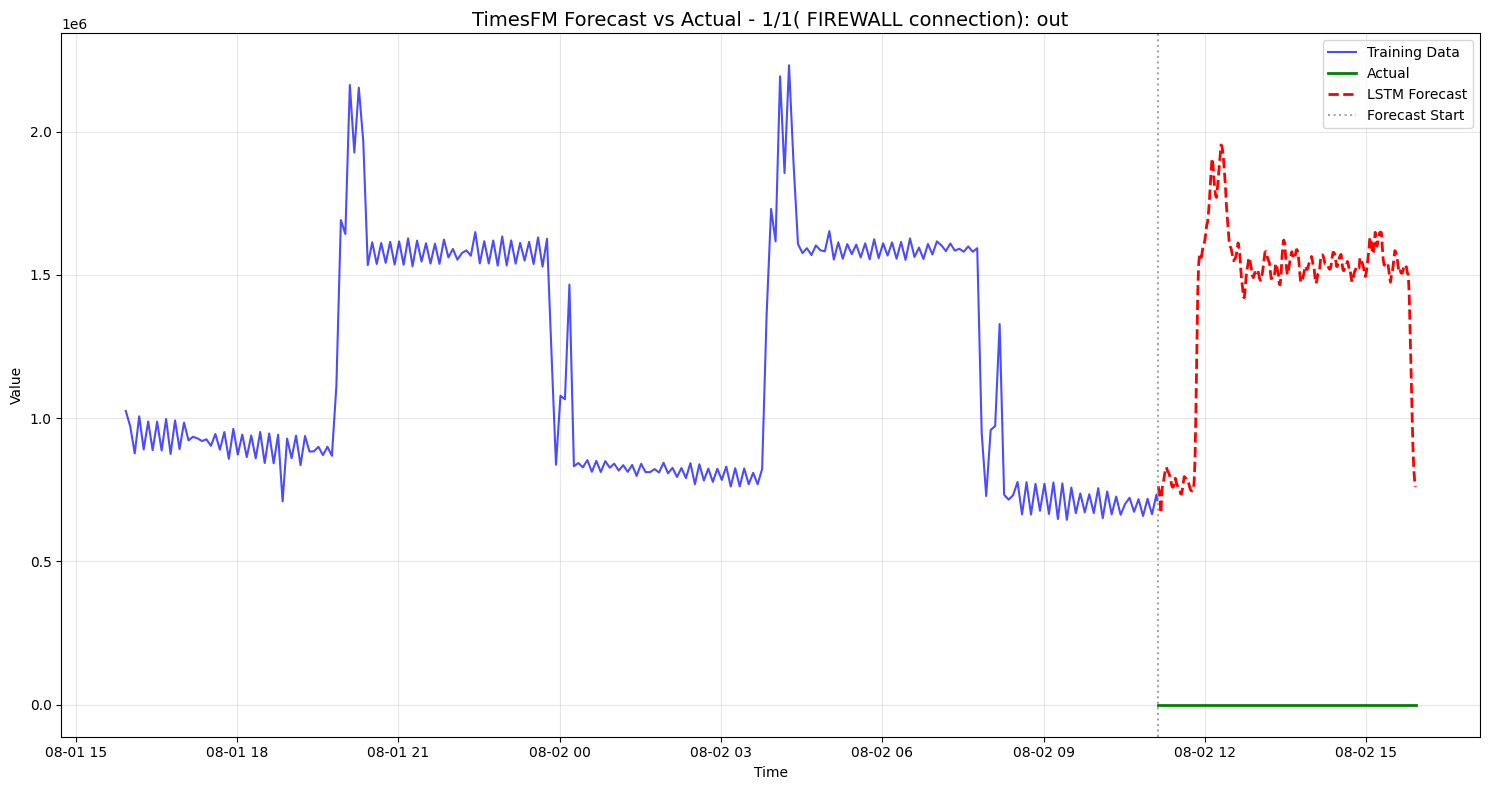

Metrics for 1/1( FIREWALL connection): out:
MAE: 84441.9329, RMSE: 111785.7204


In [ ]:
results_df = pd.DataFrame(results)

# Plot individual variable
plot_single_variable_forecast(
    variable_idx=1,
    train_data_normalized=df_bits_train_scaled,
    test_data_denormalized=actuals_df,  # Fixed: using denormalized actuals
    lstm_forecast_denormalized=predictions_df,  # Fixed: using consistent naming
    scaler=scaler,
    results_df=results_df
)

# Plot summary for all variables
plot_all_variables_summary(
    test_data_denormalized=actuals_df,
    lstm_forecast_denormalized=predictions_df,
    results_df=results_df
)